In [9]:
%reload_ext autoreload
%autoreload 2

Beta for posterior: 1  with data type: <class 'int'>
K-fold number: 0  with data type: <class 'int'>
Eb_standardize_epsilon: 1287.4819202075
Ns_standardize_epsilon: 0.262291780650704
Shape of Eb_standardized_train: (256, 256, 1, 937)
Shape of Ns_standardized_train: (256, 256, 1, 937)
Shape of domain mask: (256, 256)
Shape of flight mask: (256, 256)
PCA model saved to self.pca_x and self.pca_y.
Shape of XY_train: (937, 65)
Shape of XY_validation: (0, 65)
Shape of XY_test: (105, 65)
GMM training completed in 0.06 seconds.
shape of Y_obs: (256, 256)
Density at init: [5.57584406e-07]
 Likelihood: 96876.311, Prior: 14.400
 Likelihood: 307830.855, Prior: 158.667
 Likelihood: 89161.543, Prior: 18.004
 Likelihood: 88024.869, Prior: 20.089
 Likelihood: 82893.460, Prior: 57.068
 Likelihood: 80955.351, Prior: 91.317
 Likelihood: 79103.123, Prior: 150.631
 Likelihood: 78141.736, Prior: 143.211
 Likelihood: 77615.592, Prior: 131.635
 Likelihood: 77485.732, Prior: 126.937
 Likelihood: 77265.150, Pri

/home/donglaiyang/Documents/Georgia-Tech/Research/GMR-inference/src/../src/amortization.py:442: RuntimeWarning: divide by zero encountered in log
  log_prob_components[:, k] = np.log(gmm.priors[k]) + log_norm + log_exponent
/home/donglaiyang/Documents/Georgia-Tech/Research/GMR-inference/src/../src/optimization.py:278: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Eb_star_tensor = torch.tensor(Eb_star, requires_grad=True)
/home/donglaiyang/Documents/Georgia-Tech/Research/GMR-inference/src/../src/optimization.py:131: RuntimeWarning: divide by zero encountered in log
  component_log_probs[k] = np.log(gmm.priors[k]) + np.log(norm_factor) + exponent[0]


Iteration 1/10, Negative Log Posterior: 11231.4912
Starting iteration 2/10...
Iteration 2/10, Negative Log Posterior: 10819.4072
Starting iteration 3/10...
Iteration 3/10, Negative Log Posterior: 9882.7064
Starting iteration 4/10...
Iteration 4/10, Negative Log Posterior: 9531.8022
Starting iteration 5/10...
Iteration 5/10, Negative Log Posterior: 9437.3006
Starting iteration 6/10...
Iteration 6/10, Negative Log Posterior: 9278.0875
Starting iteration 7/10...
Iteration 7/10, Negative Log Posterior: 9144.8801
Starting iteration 8/10...
Iteration 8/10, Negative Log Posterior: 9020.6093
Starting iteration 9/10...
Iteration 9/10, Negative Log Posterior: 8974.2863
Starting iteration 10/10...
Iteration 10/10, Negative Log Posterior: 11575.0979


/home/donglaiyang/Documents/Georgia-Tech/Research/GMR-inference/src/../src/optimization.py:326: RuntimeWarning: divide by zero encountered in log
  component_log_probs[k] = (np.log(gmm.priors[k])


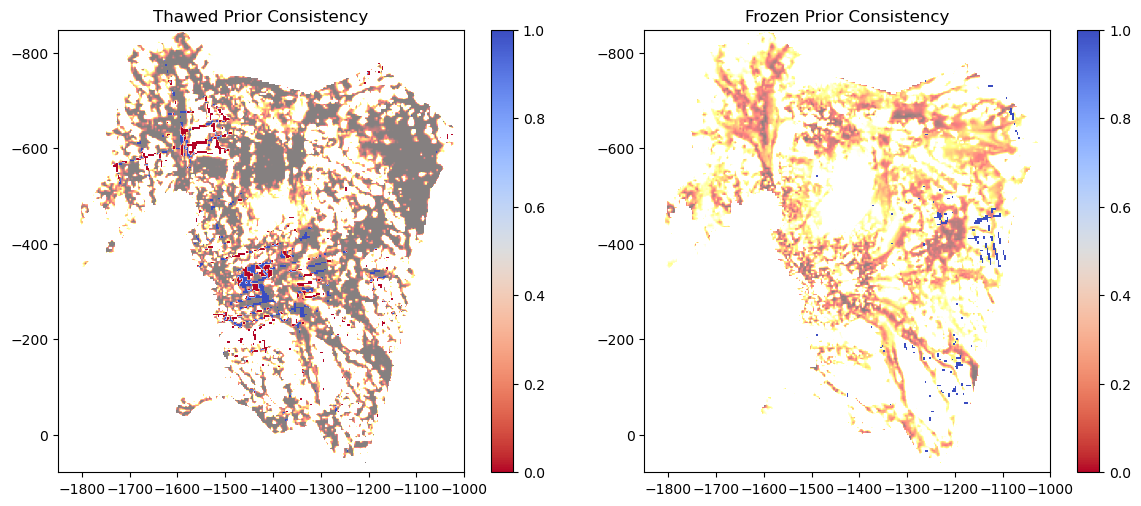

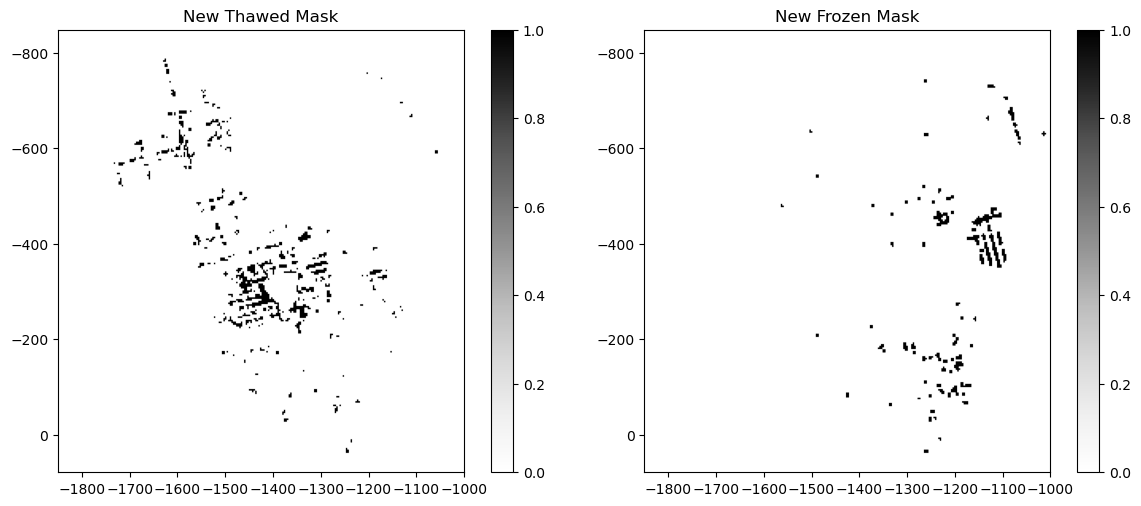

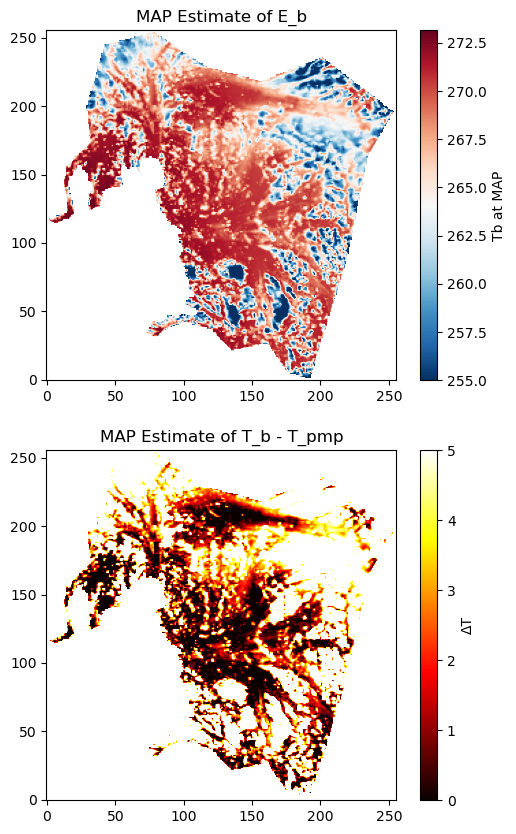

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
# load .mat data
import scipy.io
# add ../ to the path
import sys
sys.path.append('../')

import src.model as model
from src.ice import compute_pmp
from src.utilities import reverse_standardize
from src.ice import enthalpy_to_temperature
# ------------------------------------------------------------------
# -------------------- KEY VALIDATION PARAMETER --------------------
beta_posterior = 1.0
kfold_num      = 0
print("Beta for posterior:", beta_posterior, " with data type:", type(beta_posterior))
print("K-fold number:", kfold_num, " with data type:", type(kfold_num))
# ------------------------------------------------------------------
# ------------------------------------------------------------------

n_optimal     = 20 # number of Gaussian components in GMM for P(Eb, Ns)
beta_prior    = 0.00001 # beta for the prior model. Small -> favors the observational data
beta_w        = 0.01 # water fraction limit
n_component_x = 50 # number of PCA components for Eb
n_component_y = 15 # number of PCA components for Ns
lambda1       = 1  # prior covariance weight 1
lambda2       = 5  # prior covariance weight 2; probably the learned variance? need to verify

err_prior_eps = 1 # error margin in prior predictive check

data_path       = os.getenv('DATA_PATH')
param_path      = os.getenv('PARAM_PATH')
mcmc_md_name    = f"mcmc_run_beta_{beta_posterior}_kfold_{kfold_num}.pt"
split_data_path = "../data/train-validate-test/" # split data set
fig_save_path    = "../figs/parameter-tuning/"
folder = data_path
# ------------------------------------------------- LOAD SIMULATION DATA -------------------------------------------------
# get the DATA_PATH from the environment variable
XY_train_filename    = "train_data.npz"
XY_valid_filename    = "validation_data.npz"
XY_test_filename     = "test_data.npz"
H_filename           = 'H_gridded.mat'
Y_obs_filename       = "Ns_obs_gridded.mat"
mask_filename        = 'training_mask.mat' 
model_bound_filename = 'training_mask_domain_continuous.mat'
# also the mean and std of Eb for reverse standardization
Eb_mean_filename     = 'trainingAll_Eb_sim_mean.mat'
Eb_std_filename      = 'trainingAll_Eb_sim_std.mat'
# also the mean and std of Ns for standardization of observed data
Ns_mean_filename     = 'trainingAll_Ns_sim_mean_masked.mat'
Ns_std_filename      = 'trainingAll_Ns_sim_std_masked.mat'
# others
coord_filename       = "trainingAll_image_coord.mat"

# preprocessing parameter file: read the csv file
preprocess_param = pd.read_csv(param_path, index_col=0)
Eb_standardize_epsilon = preprocess_param['Eb_standardization_epsilon'].values[0]
Ns_standardize_epsilon = preprocess_param['Ns_standardization_epsilon'].values[0]
print("Eb_standardize_epsilon:", Eb_standardize_epsilon)
print("Ns_standardize_epsilon:", Ns_standardize_epsilon)


flight_mask_data = scipy.io.loadmat(folder + mask_filename) # this is the flightline mask
H_data           = scipy.io.loadmat(folder + H_filename)
model_bound_data = scipy.io.loadmat(folder + model_bound_filename) # this is model domain mask
coord_data       = scipy.io.loadmat(folder + coord_filename)
# standardization data for Eb
Eb_mean          = scipy.io.loadmat(folder + Eb_mean_filename)
Eb_std           = scipy.io.loadmat(folder + Eb_std_filename)
# standardization factors
Eb_mean_data     = scipy.io.loadmat(folder + Eb_mean_filename)
Eb_std_data      = scipy.io.loadmat(folder + Eb_std_filename)
# replace nan by 0 for downstream tasks
Eb_mean_data     = np.nan_to_num(Eb_mean_data['Eb_mean'], nan=0.0)
Eb_std_data      = np.nan_to_num(Eb_std_data['Eb_std'], nan=0.0)

# compute pmp
H = H_data['H_struct']['H'][0][0].flatten()
X = H_data['H_struct']['X'][0][0].flatten()
Y = H_data['H_struct']['Y'][0][0].flatten()
pmp = compute_pmp(H)

# load
Eb_standardized_train = np.load(split_data_path + XY_train_filename)['Eb_train']
Ns_standardized_train = np.load(split_data_path + XY_train_filename)['Ns_train']
Eb_standardized_valid = np.load(split_data_path + XY_valid_filename)['Eb_validation']
Ns_standardized_valid = np.load(split_data_path + XY_valid_filename)['Ns_validation']
Eb_standardized_test  = np.load(split_data_path + XY_test_filename)['Eb_test']
Ns_standardized_test  = np.load(split_data_path + XY_test_filename)['Ns_test']
# replace nan by 0
Eb_mean = np.nan_to_num(Eb_mean['Eb_mean'], nan=0.0).flatten()
Eb_std  = np.nan_to_num(Eb_std['Eb_std'], nan=0.0).flatten()

# load model boundary
model_bound_data_ori = model_bound_data['in_domain_mask'].astype(bool)

x_coord = coord_data['training_coord'][0][0][0]
y_coord = coord_data['training_coord'][0][0][1]
extent = np.array([x_coord.min(), x_coord.max(), y_coord.max(), y_coord.min()])/1e3 # convert to km (left, right, bottom, top), imshow by default is inverted in y-axis

# -------------------------------------------------- LOAD OBSERVATION DATA --------------------------------------------------
Y_obs_data   = scipy.io.loadmat(folder + Y_obs_filename)
# standardization data for Ns
Ns_mean_data = scipy.io.loadmat(folder + Ns_mean_filename)
Ns_std_data  = scipy.io.loadmat(folder + Ns_std_filename)
Ns_mean = Ns_mean_data['Ns_mean_masked']
Ns_std = Ns_std_data['Ns_std_masked']  

Y_obs_data     = Y_obs_data['atten_rate_grid']
atten_rate_avg = Y_obs_data['atten_avg'][0][0]

# apply flightline masking to the standardization mean and std
flight_mask = flight_mask_data['mask']
flight_mask_bool = flight_mask.astype(bool)
Ns_mean_masked = Ns_mean.copy()
Ns_mean_masked[~flight_mask_bool] = 0 # set the mean to 0
Ns_std_masked = Ns_std.copy()
Ns_std_masked[~flight_mask_bool] = 1 # set the std to 1

Ns_mean_masked = Ns_mean_masked.flatten()   
Ns_std_masked  = Ns_std_masked.flatten()

print('Shape of Eb_standardized_train:', Eb_standardized_train.shape)
print('Shape of Ns_standardized_train:', Ns_standardized_train.shape)
print('Shape of domain mask:', model_bound_data_ori.shape)
print('Shape of flight mask:', flight_mask_bool.shape)

# initialize the model object
md = model.model(extent=extent, coord=(x_coord, y_coord))

# load training data
# first combine all so that our PCA is operated on the whole dataset
Eb_standardized_all = np.concatenate([Eb_standardized_train, 
                                      Eb_standardized_valid, 
                                      Eb_standardized_test], 
                                      axis=3)
Ns_standardized_all = np.concatenate([Ns_standardized_train, 
                                      Ns_standardized_valid, 
                                      Ns_standardized_test], 
                                      axis=3)
md.load_sim_data(Eb_standardized_all, Ns_standardized_all, 
                 domain_mask=model_bound_data_ori, 
                 flight_mask=flight_mask_bool, 
                 show_plot=False)

md.load_standardization_data(X_mean=Eb_mean, X_std=Eb_std,
                             Y_mean=Ns_mean_masked, Y_std=Ns_std_masked,
                             X_epsilon=Eb_standardize_epsilon, Y_epsilon=Ns_standardize_epsilon)

# reduce dim with PCA. 
md.find_reduction_model_pca(n_component_x=n_component_x, n_component_y=n_component_y)

# load specifically the train, validation, and test (pre-split) data and apply the fitted PCA
md.load_split_data(X_train=Eb_standardized_train,      Y_train=Ns_standardized_train,
                   X_validation=Eb_standardized_valid, Y_validation=Ns_standardized_valid,
                   X_test=Eb_standardized_test,        Y_test=Ns_standardized_test)

# train GMM
md.train_gmm_XY(n_components=n_optimal)
md.load_obs_data(atten_rate_avg, show_plot=False)
md.derive_prior(beta=beta_prior, lambda1=lambda1, lambda2=lambda2, show_plot=False)

# --------------- load basal thermal evidence -----------------
# (from one of the folds)
# load a subset of the k-fold cross validation data
cv_mask = np.load(split_data_path + f"cv_fold_{kfold_num}_masks.npz")
cv_area = np.load(split_data_path + f"cv_fold_{kfold_num}_areas.npz")

train_thawed_mask      = cv_mask['train_thawed']
train_frozen_mask      = cv_mask['train_frozen']
train_thawed_frac_area = cv_area['train_thawed_area']
train_frozen_frac_area = cv_area['train_frozen_area']

thawed_mask_data = np.zeros_like(train_thawed_mask, dtype=int)
frozen_mask_data = np.zeros_like(train_frozen_mask, dtype=int)
thawed_mask_data[train_thawed_mask] = 1
frozen_mask_data[train_frozen_mask] = 1

md.load_evidence(thawed_mask_data.flatten(), train_thawed_frac_area.flatten(),
                 frozen_mask_data.flatten(), train_frozen_frac_area.flatten(),
                 pmp,
                 show_plot=False)

# ---------------- PRIOR predictive check and filtering ----------------
from src.utilities import reverse_standardize
from src.ice import enthalpy_to_temperature
# sample from prior and compute the likelihood
n_prior_samples = 2000
prior_samples = md.gmm_prop.sample(n_prior_samples)

n_frozen = np.sum(md.frozen_mask)
n_thawed = np.sum(md.thawed_mask)
print("Number of frozen grid points:", n_frozen)
print("Number of thawed grid points:", n_thawed)

thawed_consistent = np.zeros(n_prior_samples,)
frozen_consistent = np.zeros(n_prior_samples,)
Tb_prior_samples = np.zeros((n_prior_samples, md.domain_mask.sum()))  
for i, sample in enumerate(prior_samples):
    Eb_sample = md.pca_x.inverse_transform(sample)
    Eb_sample_ori = reverse_standardize(Eb_sample,
                                        md.X_mean, 
                                        md.X_std, 
                                        method='relaxation',
                                        epsilon=md.X_epsilon)
    Tb_sample_ori = enthalpy_to_temperature(Eb_sample_ori, md.pmp, istorch=False)
    Tb_prior_samples[i] = Tb_sample_ori[md.domain_mask.flatten()]

    thawed = (Tb_sample_ori - md.pmp) >= -1
    frozen = (md.pmp - Tb_sample_ori) >= 1

    thawed[md.domain_mask.flatten() == False] = np.nan
    frozen[md.domain_mask.flatten() == False] = np.nan

    frozen_consistent[i] = np.nansum(frozen[md.frozen_mask==True])
    thawed_consistent[i] = np.nansum(thawed[md.thawed_mask==True])

    if i % 500 == 0:
        print("Sample {}/{}".format(i, n_prior_samples))

# Compute percentiles across samples (axis=0 → per pixel)
Tb_plow  = np.nanpercentile(Tb_prior_samples, 1,  axis=0)
Tb_phigh = np.nanpercentile(Tb_prior_samples, 99, axis=0)

# Reconstruct spatial maps
domain_idx   = np.where(md.domain_mask.flatten())[0]
Tb_plow_map  = np.full(md.domain_mask.flatten().shape, np.nan)
Tb_phigh_map = np.full(md.domain_mask.flatten().shape, np.nan)
Tb_plow_map[domain_idx]  = Tb_plow
Tb_phigh_map[domain_idx] = Tb_phigh

# Thawed: 99th percentile of Tb must be below pmp - err_prior_eps  (i.e. Tb_high < pmp - ε)
# Frozen:  1st percentile of Tb must be above pmp + err_prior_eps  (i.e. Tb_low  > pmp + ε)

flat_shape  = md.thawed_mask.size  
thawed_mask = md.thawed_mask.flatten().astype(bool)
frozen_mask = md.frozen_mask.flatten().astype(bool)

# ── Percentile deltas relative to pressure-melting point ─────────────────────
thawed_delta = np.full(flat_shape, np.nan)
frozen_delta = np.full(flat_shape, np.nan)

thawed_delta[thawed_mask] = Tb_phigh_map.flatten()[thawed_mask] - md.pmp.flatten()[thawed_mask]
frozen_delta[frozen_mask] = Tb_plow_map.flatten()[frozen_mask]  - md.pmp.flatten()[frozen_mask]

# ── Consistency flags ─────────────────────────────────────────────────────────
thawed_consistent = np.where(thawed_mask, thawed_delta > -err_prior_eps, np.nan)
frozen_consistent = np.where(frozen_mask,  frozen_delta  < -err_prior_eps, np.nan)

# ── Plot ──────────────────────────────────────────────────────────────────────
grid_shape = (md.ny, md.nx)
vlims = [(0, 3), (0, 10)]
plot_pairs = [
    (md.pmp.reshape(md.ny, md.nx) - Tb_phigh_map.reshape(md.ny, md.nx), thawed_consistent, "Thawed Prior Consistency", vlims[0]),
    (md.pmp.reshape(md.ny, md.nx) - Tb_plow_map.reshape(md.ny, md.nx), frozen_consistent,  "Frozen Prior Consistency", vlims[1]),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (bg, data, title, vlim) in zip(axes, plot_pairs):
    imbg = ax.imshow(bg.reshape(grid_shape), extent=md.extent,
                     origin='lower', cmap='hot',
                     vmin=vlim[0], vmax=vlim[1],
                     alpha=0.5, zorder=1)
    im = ax.imshow(data.reshape(grid_shape), extent=md.extent,
                   origin='lower', cmap='coolwarm_r',
                   vmin=0, vmax=1,
                   alpha=1, zorder=2)
    ax.set_title(title)
    fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.savefig(fig_save_path + f"prior_predictive_check_kfold_{kfold_num}_beta_{beta_posterior}.png", dpi=300)

# subselect the valid thawed and frozen evidence based on this prior check
new_thawed_mask = np.where(thawed_consistent == 1, True, False)
new_frozen_mask = np.where(frozen_consistent == 1, True, False)
# convert to 0 and 1
new_thawed_mask = new_thawed_mask.astype(int)
new_frozen_mask = new_frozen_mask.astype(int)
# make new plots for visual inspection
plt.figure(figsize=(12, 5))
plt.subplot(1,2,1)
plt.imshow(new_thawed_mask.reshape(grid_shape), extent=md.extent, origin='lower', cmap='Greys',
           vmin=0, vmax=1)
plt.title("New Thawed Mask")
plt.colorbar()

plt.subplot(1,2,2)
plt.imshow(new_frozen_mask.reshape(grid_shape), extent=md.extent, origin='lower', cmap='Greys',
           vmin=0, vmax=1)
plt.title("New Frozen Mask")
plt.colorbar()

plt.tight_layout()
plt.savefig(fig_save_path + f"filtered_evidence_kfold_{kfold_num}_beta_{beta_posterior}.png", dpi=300)

# do the same for fractional area
new_thawed_fractional_area = np.where(thawed_consistent == 1, md.thawed_fractional_area, 0)
new_frozen_fractional_area = np.where(frozen_consistent == 1, md.frozen_fractional_area, 0)

# reload the evidence with the filtered masks and fractional areas
md.load_evidence(new_thawed_mask.flatten(), new_thawed_fractional_area.flatten(),
                 new_frozen_mask.flatten(), new_frozen_fractional_area.flatten(),
                 pmp,
                 show_plot=False)

print("\n Start computing MAP (initial point for posterior sampling)")
md.compute_MAP(beta=beta_posterior, beta_w=beta_w, n_iter=10, lr=0.1, show_plot=True)



In [14]:
md.analyze_posterior_samples(beta=beta_posterior, loading=True, savename=mcmc_md_name)

Loaded samples from ../data/posterior-hmc-models/mcmc_run_beta_1.0_kfold_0.pt
HMC Sampling Complete. Extracted shape: (3000, 50)
Sample: 3000/3000
Eb samples saved to ../data/posterior-hmc-samples/ with savename=mcmc_run_beta_1.0_kfold_0.pt


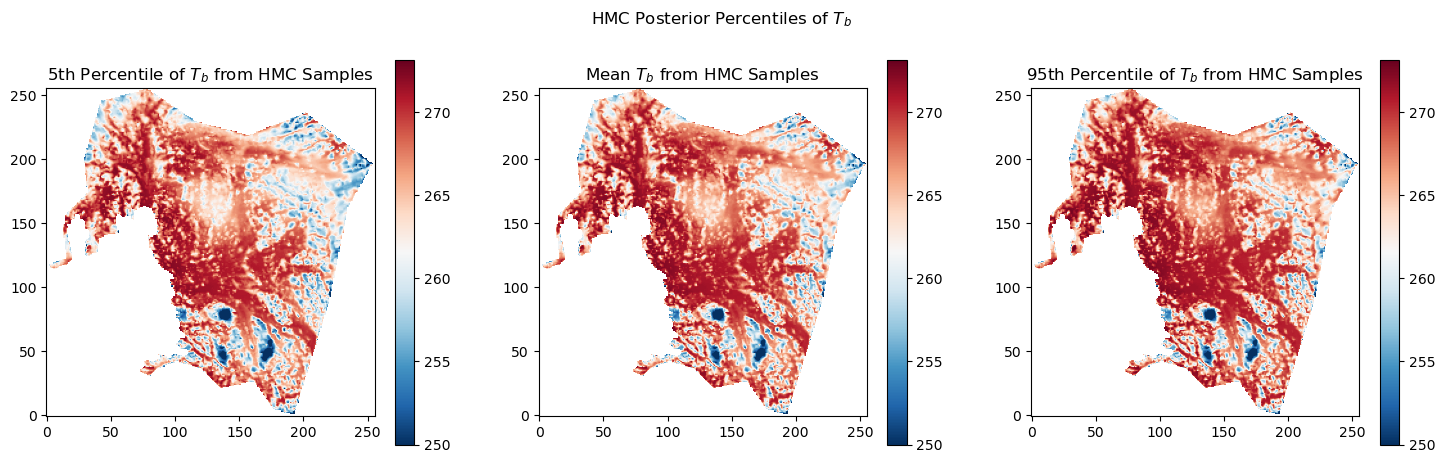

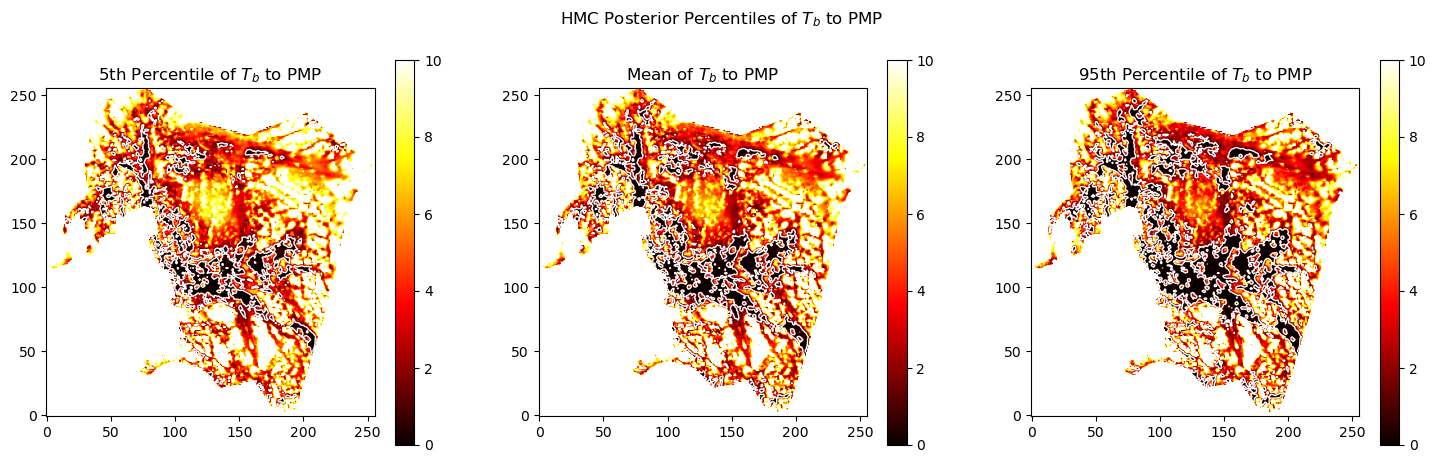

In [15]:
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
plt.imshow(md.Tb_p5, cmap='RdBu_r', vmin=250, vmax=273.15)
plt.title('5th Percentile of $T_b$ from HMC Samples')
plt.colorbar()
plt.gca().invert_yaxis()
plt.subplot(1, 3, 2)
plt.imshow(md.Tb_mean, cmap='RdBu_r', vmin=250, vmax=273.15)
plt.title('Mean $T_b$ from HMC Samples')
plt.colorbar()
plt.gca().invert_yaxis()
plt.subplot(1, 3, 3)
plt.imshow(md.Tb_p95, cmap='RdBu_r', vmin=250, vmax=273.15)
plt.title('95th Percentile of $T_b$ from HMC Samples')
plt.colorbar()
plt.gca().invert_yaxis()
plt.suptitle('HMC Posterior Percentiles of $T_b$')
plt.show()

deg2pmp_p5 = (md.pmp - md.Tb_p5.flatten()).reshape(md.nx, md.ny)
deg2pmp_mean = (md.pmp - md.Tb_mean.flatten()).reshape(md.nx, md.ny)
deg2pmp_p95 = (md.pmp - md.Tb_p95.flatten()).reshape(md.nx, md.ny)
deg2pmp_p5[md.domain_mask == False] = np.nan
deg2pmp_mean[md.domain_mask == False] = np.nan
deg2pmp_p95[md.domain_mask == False] = np.nan
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
plt.imshow(deg2pmp_p5, cmap='hot', vmin=0, vmax=10)
plt.colorbar()  
# add contourline of 1
plt.contour(deg2pmp_p5, levels=[1], colors='white', linewidths=1)
plt.title('5th Percentile of $T_b$ to PMP')
plt.gca().invert_yaxis()

plt.subplot(1, 3, 2)
plt.imshow(deg2pmp_mean , cmap='hot', vmin=0, vmax=10)
plt.colorbar()
# add contourline of 1
plt.contour(deg2pmp_mean, levels=[1], colors='white', linewidths=1)
plt.gca().invert_yaxis()
plt.title('Mean of $T_b$ to PMP')

plt.subplot(1, 3, 3)
plt.imshow(deg2pmp_p95 , cmap='hot', vmin=0, vmax=10)
plt.colorbar()
# add contourline of 1
plt.contour(deg2pmp_p95, levels=[1], colors='white', linewidths=1)
plt.title('95th Percentile of $T_b$ to PMP')
plt.gca().invert_yaxis()
plt.suptitle('HMC Posterior Percentiles of $T_b$ to PMP')
plt.savefig("../figs/posterior_5-mean-95_deg2pmp.png", dpi=300)
plt.show()

--- HMC Sampling Metrics ---
Total Samples Drawn: 3000
Mean ESS across all dimensions: 2073.50
Minimum ESS (Worst mixing dimension): 1232.17
Maximum ESS (Best mixing dimension): 3022.87
Post-Burn-in Mean ESS: 1384.08
Post-Burn-in Min ESS: 745.59


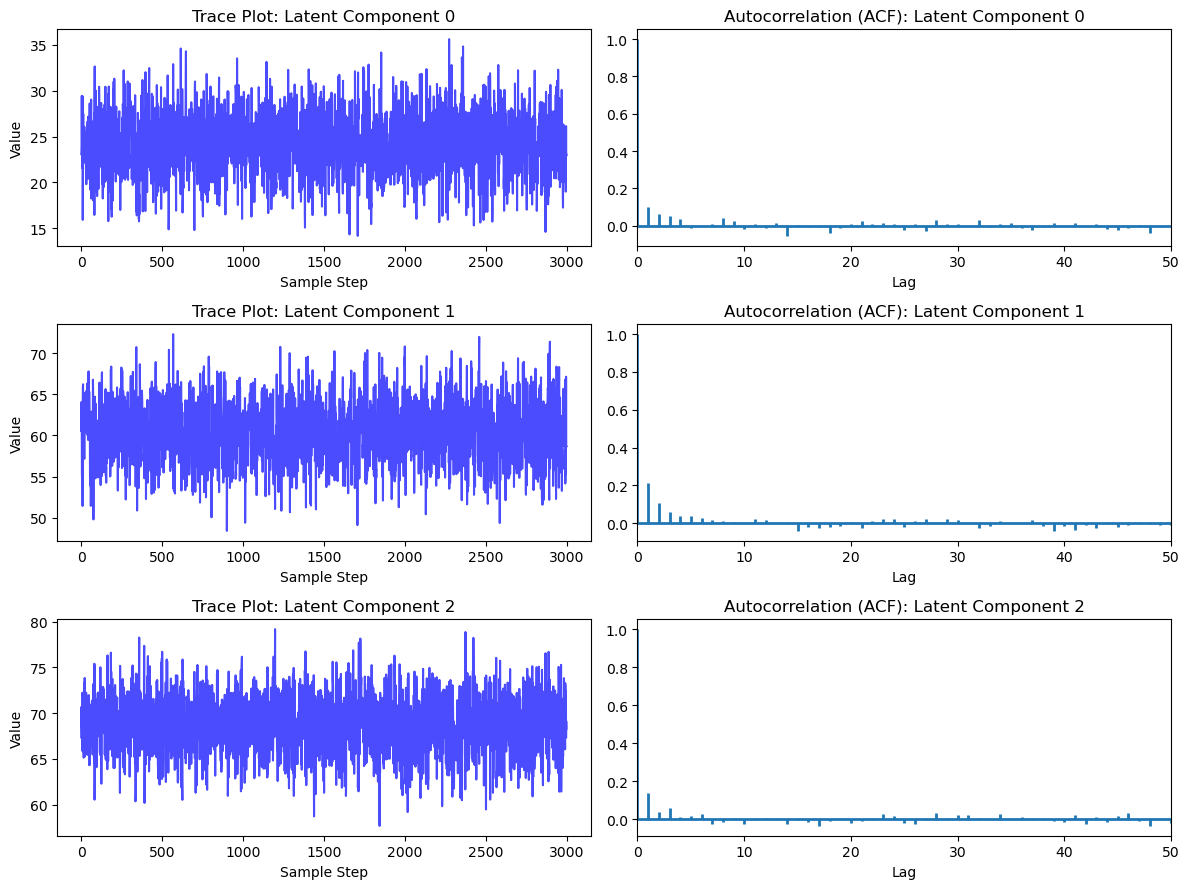

In [16]:
md.posterior_quality_check()